### Import the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Finance Project environment is ready!")

Finance Project environment is ready!


### Load application_train.csv

In [2]:
df = pd.read_csv(r"D:\Shrabani.Personal\Self_Project\Finance_project\Data\application_train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (307511, 122)


In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.tail(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307501,456245,0,Cash loans,F,N,Y,3,81000.0,269550.0,11871.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307502,456246,0,Cash loans,F,N,Y,1,94500.0,225000.0,10620.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307503,456247,0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
307504,456248,0,Cash loans,F,N,Y,0,153000.0,331920.0,16096.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307505,456249,0,Cash loans,F,N,Y,0,112500.0,225000.0,22050.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


### Exploratory Data Analysis

### Check Null values

In [5]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

### Create a missing-value summary

In [7]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing.head(30)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


In [8]:
print("No missing values:",
      (missing["Missing_Percentage"] == 0).sum())

print("Less than 10% missing:",
      ((missing["Missing_Percentage"] > 0) &
       (missing["Missing_Percentage"] < 10)).sum())

print("10–30% missing:",
      ((missing["Missing_Percentage"] >= 10) &
       (missing["Missing_Percentage"] < 30)).sum())

print("30–50% missing:",
      ((missing["Missing_Percentage"] >= 30) &
       (missing["Missing_Percentage"] < 50)).sum())

print("50–70% missing:",
      ((missing["Missing_Percentage"] >= 50) &
       (missing["Missing_Percentage"] < 70)).sum())

print("70%+ missing:",
      (missing["Missing_Percentage"] >= 70).sum())


No missing values: 55
Less than 10% missing: 10
10–30% missing: 7
30–50% missing: 9
50–70% missing: 41
70%+ missing: 0


In [9]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing.head(30)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


In [10]:
high_missing = missing[missing["Missing_Percentage"] >= 50]

high_missing

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


### Target Column

In [12]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

### This is a strongly imbalanced classification problem.

There are about 11.4 non-default applications for every 1 default application.

That means later we should not judge our model mainly by accuracy. For example, a model that predicts every applicant as 0 would already get about 91.93% accuracy, but it would detect zero defaults—which would be useless for a bank.

In [13]:
target_distribution = df["TARGET"].value_counts(normalize=True) * 100

print(f"No Default (0): {target_distribution[0]:.2f}%")
print(f"Default (1): {target_distribution[1]:.2f}%")

No Default (0): 91.93%
Default (1): 8.07%


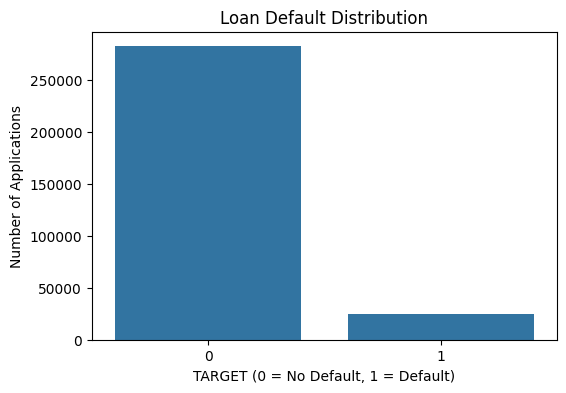

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="TARGET")

plt.title("Loan Default Distribution")
plt.xlabel("TARGET (0 = No Default, 1 = Default)")
plt.ylabel("Number of Applications")

plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [16]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [17]:
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 16
Numeric columns: 106


In [18]:
print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [19]:
financial_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

df[financial_cols].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05
mean,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05
std,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05
min,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04
25%,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05
50%,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05
75%,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05
max,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06


In [20]:
df.groupby("TARGET")[financial_cols].mean()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
TARGET,,,,
0,169077.722266,602648.282002,27163.623349,542736.795003
1,165611.760906,557778.527674,26481.744290,488972.412554


### compare medians

In [21]:
df.groupby("TARGET")[financial_cols].median()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
TARGET,,,,
0,148500.0,517788.0,24876.0,450000.0
1,135000.0,497520.0,25263.0,450000.0


### create financial ratios

In [22]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["GOODS_INCOME_RATIO"] = (
    df["AMT_GOODS_PRICE"] / df["AMT_INCOME_TOTAL"]
)

In [23]:
ratio_cols = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "GOODS_INCOME_RATIO"
]

df.groupby("TARGET")[ratio_cols].mean()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_INCOME_RATIO
TARGET,,,
0,3.963729,0.180530,3.556969
1,3.887438,0.185482,3.400317


In [24]:
df.groupby("TARGET")[ratio_cols].median()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_INCOME_RATIO
TARGET,,,
0,3.266653,0.162280,2.942308
1,3.253143,0.169294,2.857143


### income distribution by default status.

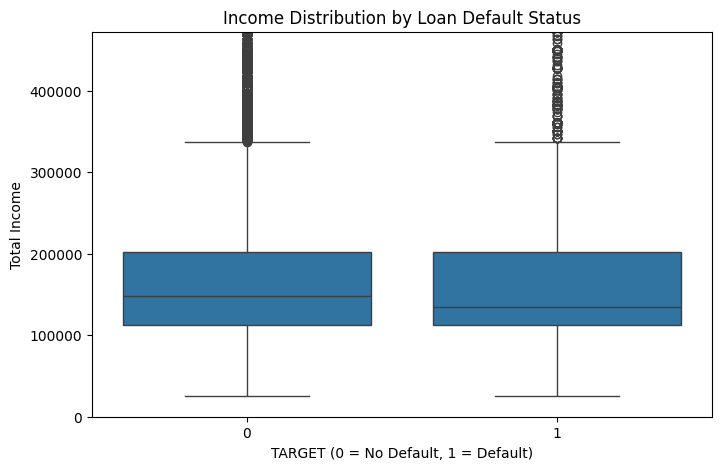

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.title("Income Distribution by Loan Default Status")
plt.xlabel("TARGET (0 = No Default, 1 = Default)")
plt.ylabel("Total Income")

plt.ylim(0, df["AMT_INCOME_TOTAL"].quantile(0.99))

plt.show()


### Income alone does not clearly separate defaulting and non-defaulting applicants.


In [26]:
df["INCOME_GROUP"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [27]:
income_default_rate = (
    df.groupby("INCOME_GROUP", observed=True)["TARGET"]
      .mean() * 100
)

income_default_rate

INCOME_GROUP
Very Low     8.206248
Low          8.588320
Medium       8.684738
High         8.056891
Very High    6.519801
Name: TARGET, dtype: float64

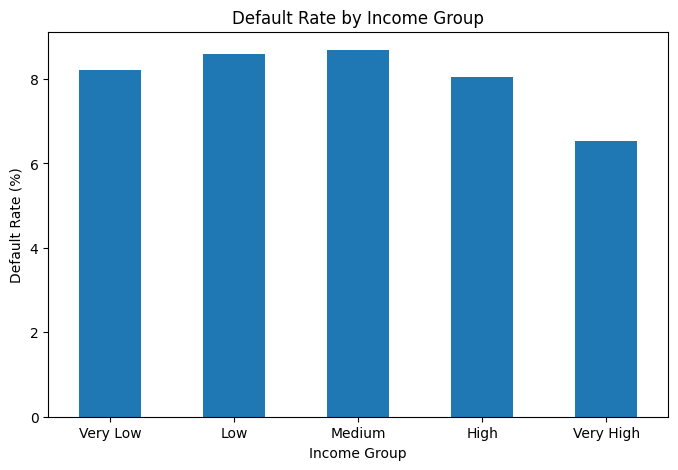

In [28]:
plt.figure(figsize=(8, 5))

income_default_rate.plot(kind="bar")

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

### The main observation is:

The Very High income group has a noticeably lower default rate than the other income groups.

But the relationship isn't perfectly linear. The low and medium groups actually have slightly higher default rates than the very-low group.


### Age and default risk

In [29]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

In [30]:
df["AGE_YEARS"].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64

In [31]:
df.groupby("TARGET")["AGE_YEARS"].agg(["mean", "median"])

,mean,median
TARGET,,
0,44.183919,43.468857
1,40.752438,39.101985


In [32]:
df["AGE_GROUP"] = pd.cut(
    df["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70"],
    include_lowest=True
)

In [33]:
### Calculate default rate:

age_default_rate = (
    df.groupby("AGE_GROUP", observed=True)["TARGET"]
      .mean() * 100
)

age_default_rate

AGE_GROUP
20-30    11.443810
30-40     9.589673
40-50     7.642888
50-60     6.119602
60-70     4.919798
Name: TARGET, dtype: float64

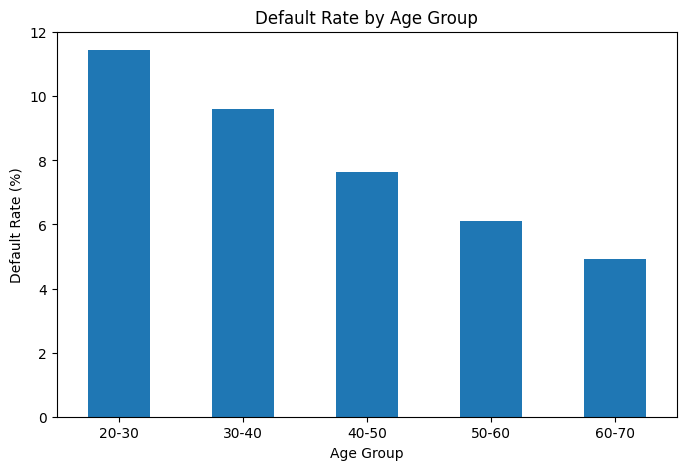

In [34]:
plt.figure(figsize=(8, 5))

age_default_rate.plot(kind="bar")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

### There is a clear downward trend:

Younger applicants have substantially higher observed default rates than older applicants.

The youngest group has a default rate more than 2× that of the 60–70 group.


### actual age distribution by target

In [35]:
df.groupby("TARGET")["AGE_YEARS"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
TARGET,,,,
0,44.183919,43.468857,20.503765,69.073238
1,40.752438,39.101985,21.021218,68.906229


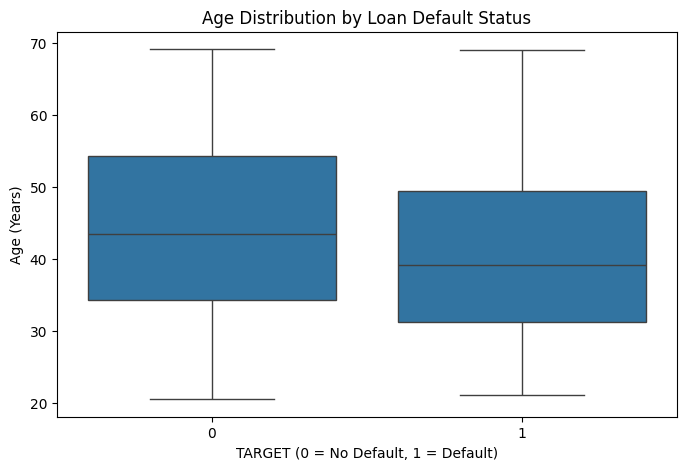

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="AGE_YEARS"
)

plt.title("Age Distribution by Loan Default Status")
plt.xlabel("TARGET (0 = No Default, 1 = Default)")
plt.ylabel("Age (Years)")

plt.show()

### Employment Status

In [37]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

### Largest values

In [38]:
df["DAYS_EMPLOYED"].sort_values(ascending=False).head(20)

146327    365243
229266    365243
157475    365243
229294    365243
157480    365243
80598     365243
229285    365243
80597     365243
157481    365243
229277    365243
41786     365243
229274    365243
157487    365243
80593     365243
41791     365243
229242    365243
229260    365243
157491    365243
229256    365243
157496    365243
Name: DAYS_EMPLOYED, dtype: int64

### Count positive values

In [39]:
(df["DAYS_EMPLOYED"] > 0).sum()

55374

In [40]:
df.loc[
    df["DAYS_EMPLOYED"] > 0,
    "DAYS_EMPLOYED"
].value_counts().head(10)

DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64

### Replace the anomalous value with missing

In [41]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

In [42]:
df["DAYS_EMPLOYED_CLEAN"].isna().sum()

55374

### Convert employment duration into years


In [43]:
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED_CLEAN"] / 365.25

In [44]:
df["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527500
std           6.402081
min          -0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64

### Compare employment with default

In [45]:
df.groupby("TARGET")["EMPLOYMENT_YEARS"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
TARGET,,,,
0,6.675264,4.629706,-0.0,49.040383
1,4.968977,3.367556,-0.0,43.994524


### Create employment groups

In [46]:
df["EMPLOYMENT_GROUP"] = pd.cut(
    df["EMPLOYMENT_YEARS"],
    bins=[0, 2, 5, 10, 20, 50],
    labels=[
        "0-2 years",
        "2-5 years",
        "5-10 years",
        "10-20 years",
        "20+ years"
    ],
    include_lowest=True
)

In [47]:
employment_default_rate = (
    df.groupby("EMPLOYMENT_GROUP", observed=True)["TARGET"]
      .mean() * 100
)

employment_default_rate

EMPLOYMENT_GROUP
0-2 years      11.202300
2-5 years      10.075919
5-10 years      7.371553
10-20 years     5.513145
20+ years       4.182297
Name: TARGET, dtype: float64

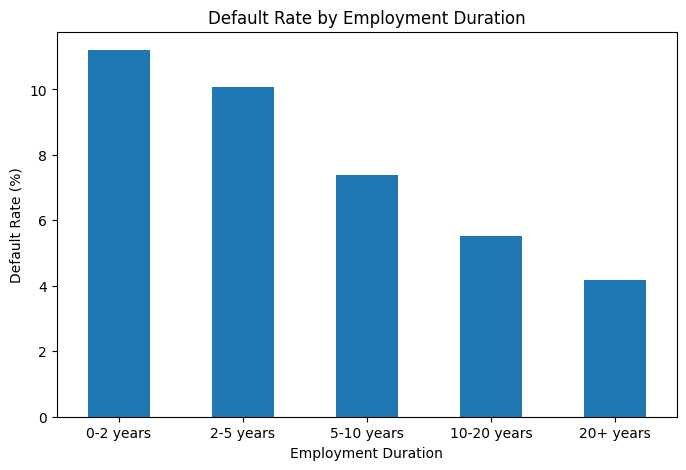

In [48]:
plt.figure(figsize=(8, 5))

employment_default_rate.plot(kind="bar")

plt.title("Default Rate by Employment Duration")
plt.xlabel("Employment Duration")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Applicants with shorter employment histories have substantially higher observed default rates.

The difference between the shortest and longest employment groups is roughly 7 percentage points.

In [49]:
df["EMPLOYMENT_MISSING"] = df["EMPLOYMENT_YEARS"].isna()

df.groupby("EMPLOYMENT_MISSING")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
EMPLOYMENT_MISSING,,
False,252137,0.086600
True,55374,0.053996


In [50]:
df.groupby("EMPLOYMENT_MISSING")["TARGET"].mean() * 100

EMPLOYMENT_MISSING
False    8.659975
True     5.399646
Name: TARGET, dtype: float64

### Loan characteristics

### Loan type vs default

In [51]:
df.groupby("NAME_CONTRACT_TYPE")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.083459
Revolving loans,29279,0.054783


In [52]:
contract_default_rate = (
    df.groupby("NAME_CONTRACT_TYPE")["TARGET"].mean() * 100
)

contract_default_rate

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64

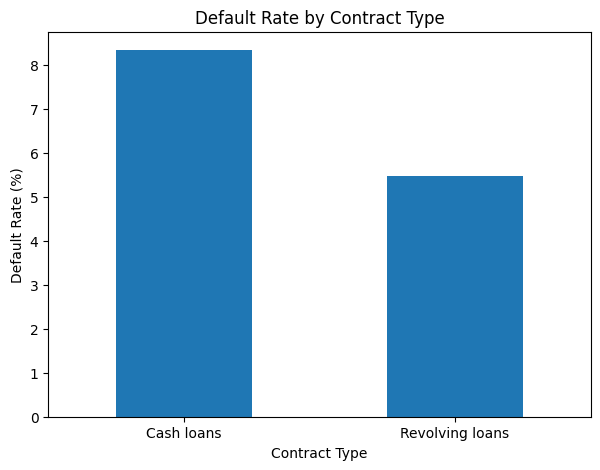

In [53]:
plt.figure(figsize=(7, 5))

contract_default_rate.plot(kind="bar")

plt.title("Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Compare loan amount by target

In [54]:
df.groupby("TARGET")[
    ["AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
].agg(["mean", "median"])

AMT_CREDIT             AMT_ANNUITY          AMT_GOODS_PRICE  \
                 mean    median          mean   median            mean   
TARGET                                                                   
0       602648.282002  517788.0  27163.623349  24876.0   542736.795003   
1       557778.527674  497520.0  26481.744290  25263.0   488972.412554   

                  
          median  
TARGET            
0       450000.0  
1       450000.0

In [55]:
df["CREDIT_BURDEN_GROUP"] = pd.qcut(
    df["CREDIT_INCOME_RATIO"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [56]:
credit_burden_default_rate = (
    df.groupby("CREDIT_BURDEN_GROUP", observed=True)["TARGET"]
      .mean() * 100
)

credit_burden_default_rate

CREDIT_BURDEN_GROUP
Very Low     7.335186
Low          8.567201
Medium       8.925259
High         8.283879
Very High    7.253776
Name: TARGET, dtype: float64

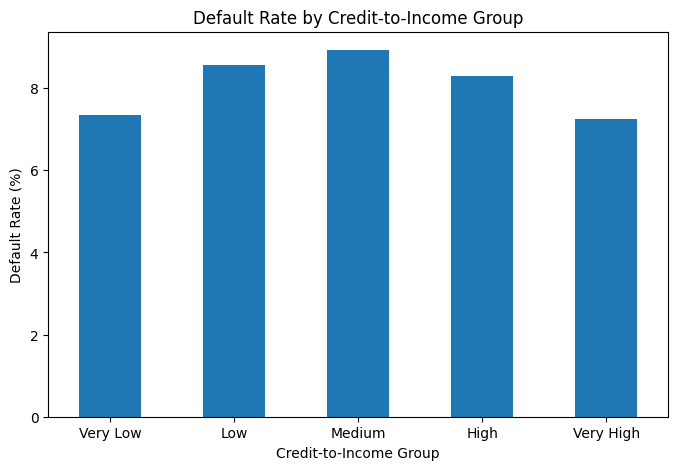

In [57]:
plt.figure(figsize=(8, 5))

credit_burden_default_rate.plot(kind="bar")

plt.title("Default Rate by Credit-to-Income Group")
plt.xlabel("Credit-to-Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

### The medium group has the highest observed default rate, while both the lowest and highest groups have lower rates.

### CREDIT_INCOME_RATIO

In [58]:
df["CREDIT_INCOME_RATIO"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
1%            0.595365
5%            1.000000
25%           2.018667
50%           3.265067
75%           5.159880
95%           9.156739
99%          13.027280
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64

In [59]:
np.isinf(df["CREDIT_INCOME_RATIO"]).sum()

0

In [60]:
df["CREDIT_INCOME_RATIO"].isna().sum()

0

### education

In [61]:
education_default_rate = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
      .agg(["count", "mean"])
)

education_default_rate["default_rate_%"] = (
    education_default_rate["mean"] * 100
)

education_default_rate.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,0.109277,10.927673
Secondary / secondary special,218391,0.089399,8.939929
Incomplete higher,10277,0.084850,8.484966
Higher education,74863,0.053551,5.355115
Academic degree,164,0.018293,1.829268


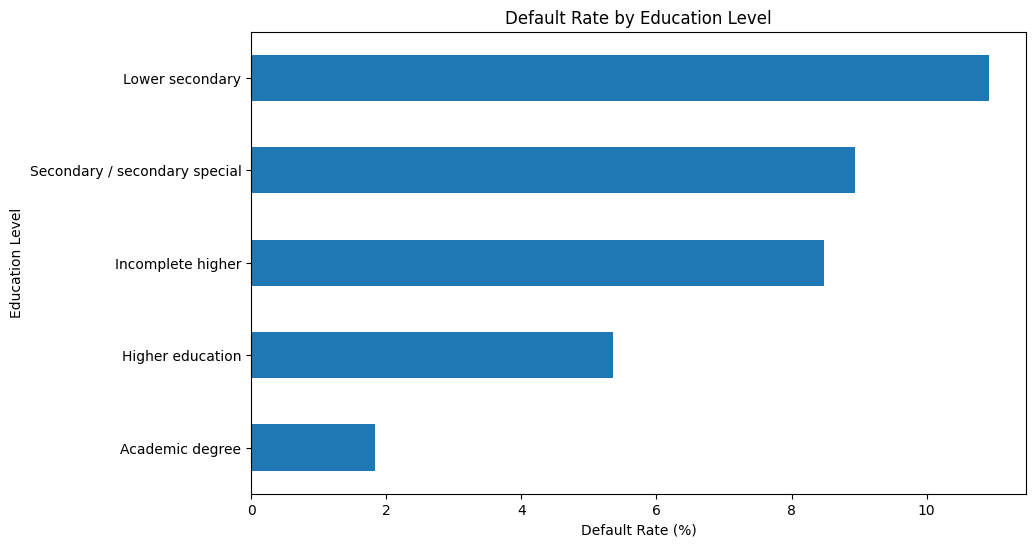

In [62]:
plt.figure(figsize=(10, 6))

education_default_rate["default_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")

plt.show()

### Applicants with higher education have substantially lower default rates than applicants with lower education levels.
### Academic degree applicants show a low observed default rate, but the category has a small sample size

### Occupation

In [63]:
occupation_default_rate = (
    df.groupby("OCCUPATION_TYPE")["TARGET"]
      .agg(["count", "mean"])
)

occupation_default_rate["default_rate_%"] = (
    occupation_default_rate["mean"] * 100
)

occupation_default_rate.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
OCCUPATION_TYPE,,,
Low-skill Laborers,2093,0.171524,17.152413
Drivers,18603,0.113261,11.326130
Waiters/barmen staff,1348,0.112760,11.275964
Security staff,6721,0.107424,10.742449
Laborers,55186,0.105788,10.578770
Cooking staff,5946,0.104440,10.443996
Sales staff,32102,0.096318,9.631799
Cleaning staff,4653,0.096067,9.606705
Realty agents,751,0.078562,7.856192


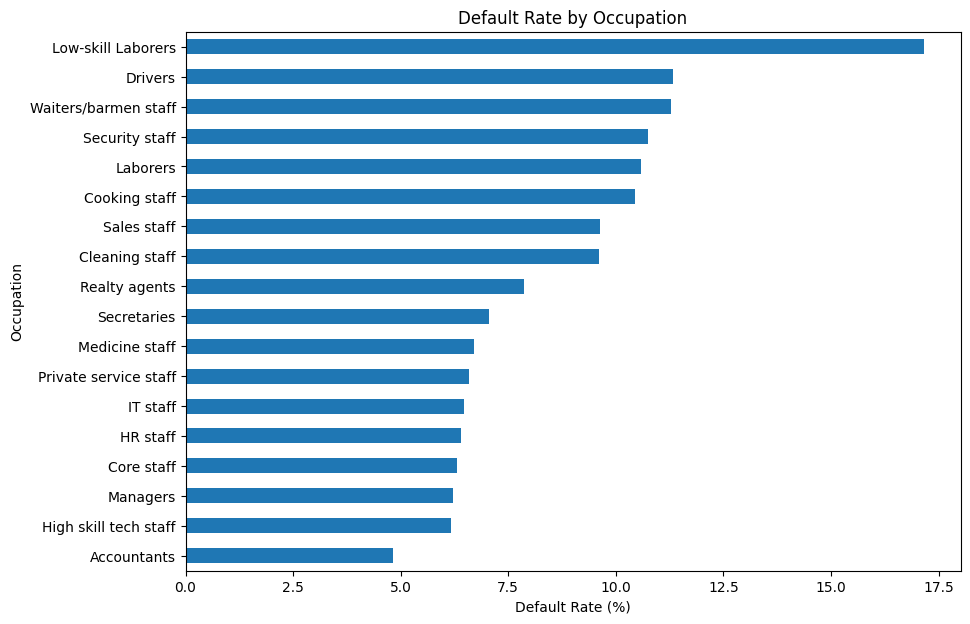

In [64]:
plt.figure(figsize=(10, 7))

occupation_default_rate["default_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Default Rate by Occupation")
plt.xlabel("Default Rate (%)")
plt.ylabel("Occupation")

plt.show()

In [65]:
occupation_default_rate.sort_values(
    "count",
    ascending=False
)

,count,mean,default_rate_%
OCCUPATION_TYPE,,,
Laborers,55186,0.105788,10.578770
Sales staff,32102,0.096318,9.631799
Core staff,27570,0.063040,6.303954
Managers,21371,0.062140,6.214028
Drivers,18603,0.113261,11.326130
High skill tech staff,11380,0.061599,6.159930
Accountants,9813,0.048303,4.830327
Medicine staff,8537,0.067002,6.700246
Security staff,6721,0.107424,10.742449


In [66]:
print("Missing occupation:", df["OCCUPATION_TYPE"].isna().sum())
print(
    "Default rate when occupation is missing:",
    df.loc[df["OCCUPATION_TYPE"].isna(), "TARGET"].mean() * 100
)


Missing occupation: 96391
Default rate when occupation is missing: 6.5130561981927775


### Since the total dataset has 307,511 applicants:

307,511
96,391
	​

×100≈31.35%

So about 31.4% of applicants have missing occupation information.

Interestingly, their default rate (6.51%) is lower than the overall default rate (8.07%).

What we'll do

We should not drop those 96,391 applicants. That's a large portion of our dataset.

For the eventual ML pipeline, we'll likely treat missing occupation as its own category:

### Income Type

In [67]:
income_type_default_rate = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
      .agg(["count", "mean"])
)

income_type_default_rate["default_rate_%"] = (
    income_type_default_rate["mean"] * 100
)

income_type_default_rate.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
NAME_INCOME_TYPE,,,
Maternity leave,5,0.400000,40.000000
Unemployed,22,0.363636,36.363636
Working,158774,0.095885,9.588472
Commercial associate,71617,0.074843,7.484257
State servant,21703,0.057550,5.754965
Pensioner,55362,0.053864,5.386366
Businessman,10,0.000000,0.000000
Student,18,0.000000,0.000000


### Default rates vary across income types, with working applicants showing a higher observed default rate than pensioners and state servants. Very small categories should be interpreted cautiously because of limited sample sizes.

### Family Status

In [68]:
family_default_rate = (
    df.groupby("NAME_FAMILY_STATUS")["TARGET"]
      .agg(["count", "mean"])
)

family_default_rate["default_rate_%"] = (
    family_default_rate["mean"] * 100
)

family_default_rate.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
NAME_FAMILY_STATUS,,,
Civil marriage,29775,0.099446,9.944584
Single / not married,45444,0.098077,9.807675
Separated,19770,0.081942,8.194234
Married,196432,0.075599,7.559868
Widow,16088,0.058242,5.824217
Unknown,2,0.000000,0.000000


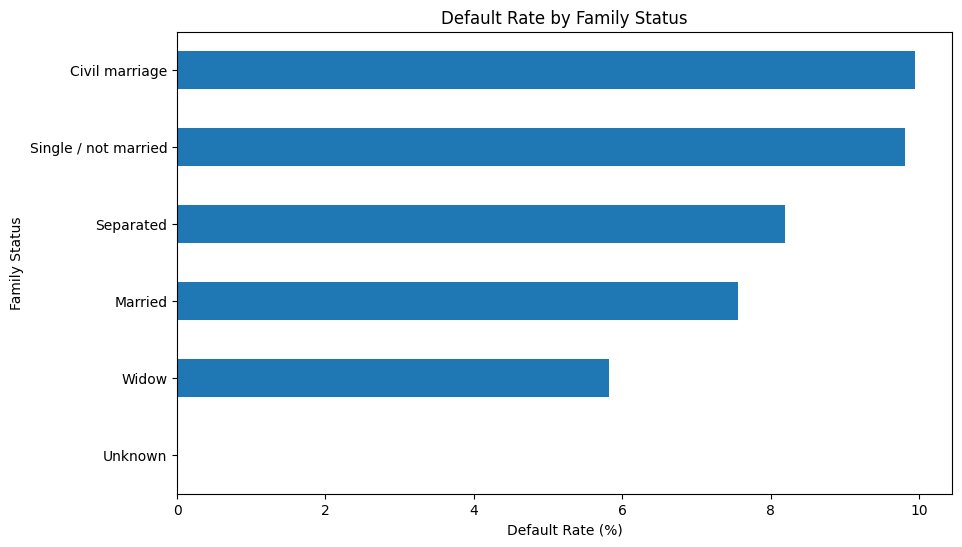

In [69]:
plt.figure(figsize=(10, 6))

family_default_rate["default_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Default Rate by Family Status")
plt.xlabel("Default Rate (%)")
plt.ylabel("Family Status")

plt.show()

### There is an observed difference across family-status groups:

Civilly married and single applicants have higher observed default rates than married or widowed applicants.

The Unknown category should obviously not be interpreted because it contains only 2 applicants.

### housing type

In [70]:
housing_default_rate = (
    df.groupby("NAME_HOUSING_TYPE")["TARGET"]
      .agg(["count", "mean"])
)

housing_default_rate["default_rate_%"] = (
    housing_default_rate["mean"] * 100
)

housing_default_rate.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
NAME_HOUSING_TYPE,,,
Rented apartment,4881,0.123131,12.313051
With parents,14840,0.116981,11.698113
Municipal apartment,11183,0.085397,8.539748
Co-op apartment,1122,0.079323,7.932264
House / apartment,272868,0.077957,7.795711
Office apartment,2617,0.065724,6.572411


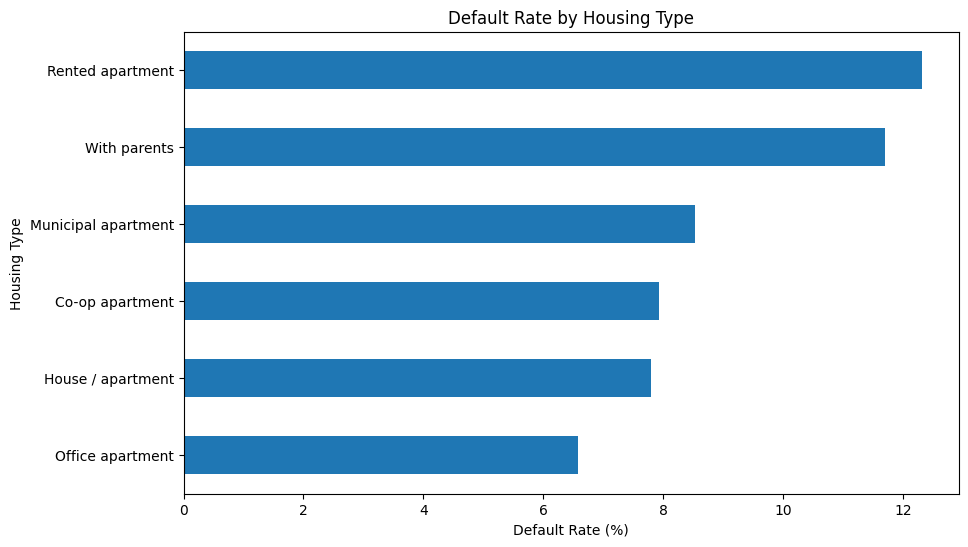

In [71]:
plt.figure(figsize=(10, 6))

housing_default_rate["default_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Default Rate by Housing Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Type")

plt.show()

### Applicants living in rented apartments or with parents have higher observed default rates than applicants living in houses/apartments.
